In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optimalinterp as oi
jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", True)

In [2]:
max_order, N_time, N_test, num_steps = 50, 257, 10, 5000
N_modes, max_period_idx = 4, 1
stochastic_basis = oi.WrappedGaussianConvolutionBasis(
    N_modes,
    max_period_idx,
    mean_0=jnp.pi,
    std_dev_0=0.1,
    mean_1=2.0,
    std_dev_1=0.5,
)
t_points, t_weights = oi.util.clenshaw_curtis(N_time)
psi = oi.basis.LinearBasis(max_order, 'chebyshev')

# choose residual_real_fcn=jnp.abs to measure error in absolute terms
optimal_interpolant = oi.optimal_interpolant.compute_optimal_psi_basis(
    stochastic_basis, allow_failure=True, N_test=N_test,
    max_optimizer_steps=num_steps,
    psi_basis = psi, t_points=t_points, t_weights=t_weights,
    atol=1e-15, rtol=1e-15, residual_real_fcn=jnp.abs
)

Step: 0, Accepted steps: 0, Steps since acceptance: 0, Loss on this step: 5517020.800424198, Loss on the last accepted step: 0.0, Step size: 1.0, y: [[ 0.   -0.01 -0.01  0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.    0.    0.  ]
 [ 0.    0.   

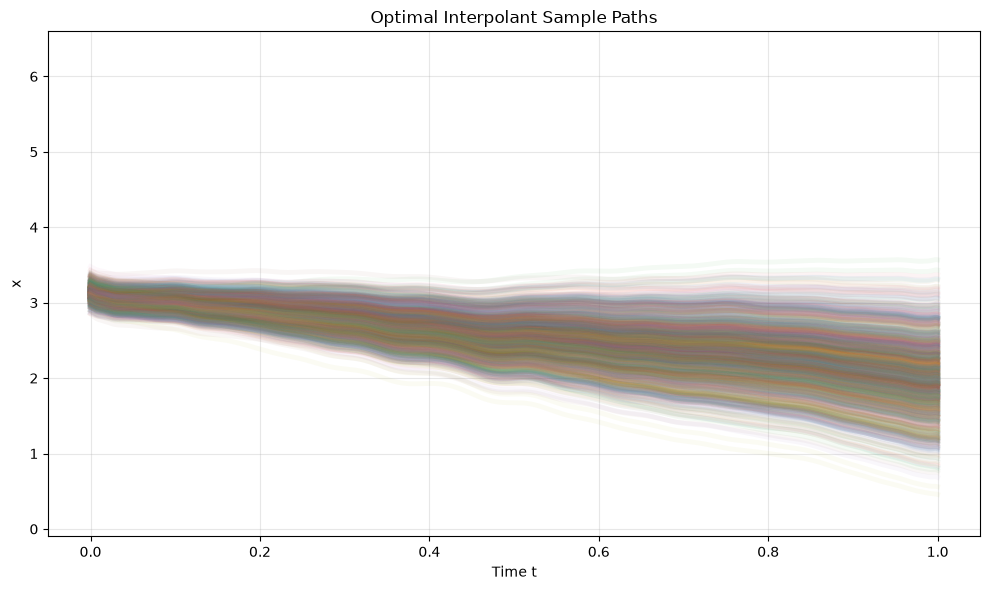

In [3]:
n_paths = 1000
t_eval = jnp.linspace(0, 1, 1001)
key = jax.random.PRNGKey(0)
sample_paths = optimal_interpolant(
    N_samples=n_paths, key=key, t_eval=t_eval
)  # Shape: (n_paths, n_times)

fig, ax = plt.subplots(figsize=(10, 6))
for i in range(n_paths):
    ax.plot(t_eval, sample_paths[i, :], alpha=0.05, linewidth=3.5)

ax.set_title("Optimal Interpolant Sample Paths")
ax.set_xlabel("Time t")
ax.set_ylabel("x")
ax.grid(True, alpha=0.3)
ax.set_ylim(-0.1, 2.1 * jnp.pi)
plt.tight_layout()
plt.show()

Finally, we can compute and visualize the mean velocity field induced by the optimal interpolant.
We use the `interpolate_velocity_field` utility function for this purpose.

In [4]:
key = jax.random.PRNGKey(42)
x_grid = jnp.linspace(0, 2*jnp.pi, 101)
if False:
    oi.visualization.visualize_interpolant_flow(
        optimal_interpolant,
        key,
        x_grid,
        bin_width=0.05,
        kernel_type="gaussian",
        N_velocity_samples=20000,
        N_flow_samples=50,
    )

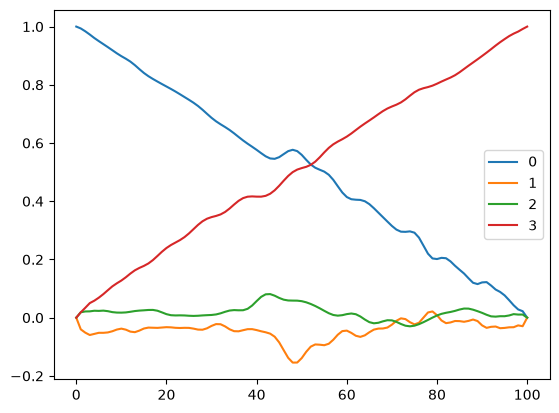

In [5]:
lb: oi.basis.AbstractLinearBasis = optimal_interpolant.psi
psi_evals = lb.evaluate_basis(jnp.linspace(0,1,101)) @ optimal_interpolant.psi_coeff
plt.plot(psi_evals)
plt.legend([str(j) for j in range(max_order)])
plt.show()